In [123]:
%pip install --upgrade  langchain langchain-google-genai "langchain[docarray]" faiss-cpu pypdf langchain_community groq langchain_groq

  Using cached groq-1.0.0-py3-none-any.whl.metadata (16 kB)


In [124]:
import os
import requests
from PIL import Image

In [125]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display, Markdown

In [126]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_groq import ChatGroq

In [127]:
from langchain_core.messages import HumanMessage, SystemMessage

In [128]:
from langchain_community.vectorstores import DocArrayInMemorySearch

In [129]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate

In [130]:
from langchain_core.documents import Document
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import CharacterTextSplitter
from langchain_community.vectorstores import FAISS

In [177]:
import os
from google.colab import userdata

GROQ_API_KEY=userdata.get('GROQ_API_KEY')
os.environ["GROQ_API_KEY"] = GROQ_API_KEY

In [133]:
model_text=load_model("llama-3.3-70b-versatile")

In [134]:
model_text.invoke("please come up with the best funny line.").content

'I told my wife she was drawing her eyebrows too high. She looked surprised.'

In [135]:
model_text.invoke(
    [
        HumanMessage(content="Answer with Simple 'Yes' or 'No'. Question: Is apple a Fruit?")
    ]
).content

'Yes.'

In [136]:
pip install -U langchain langchain-community


In [137]:
from langchain_community.vectorstores import DocArrayInMemorySearch

In [138]:
def get_image(url,filename,extension):
  content=requests.get(url).content
  with open(f'/content/{filename}.{extension}','wb') as f:
    f.write(content)
  image=Image.open(f'/content/{filename}.{extension}')
  image.show()
  return image

In [139]:
image = get_image("https://static.nike.com/a/images/t_PDP_1728_v1/f_auto,q_auto:eco/1705ca64-fbc8-4b79-a451-4ab77760c219/dunk-low-older-shoes-C7T1cx.png",
                  "nike-shoes",
                  "png")

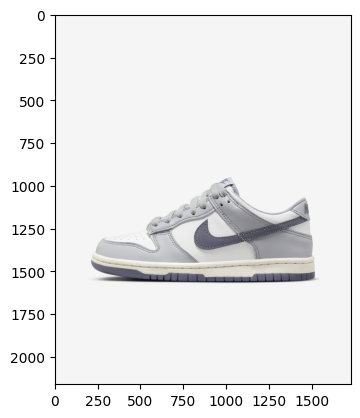

In [140]:
plt.imshow(image)
plt.show()

In [141]:
prompt="give me summary of this image in 5 words"

In [143]:
vision_model=load_model("llama-3.3-70b-versatile")

In [146]:
from langchain_community.embeddings import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)




/tmp/ipython-input-1677008560.py:3: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [147]:
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document

doc = Document(
    page_content="Grey and white Nike sneaker.",
    metadata={"source": "image_caption"}
)

vectorstore = FAISS.from_documents([doc], embeddings)

In [148]:
query = "Is this shoe suitable for running?"

docs = vectorstore.similarity_search(query, k=1)

prompt = f"""
Context:
{docs[0].page_content}

Question:
{query}

Answer clearly.
"""

response = llm.invoke(prompt)
print(response.content)


Yes, a Nike sneaker is generally suitable for running, as Nike is a well-known brand that produces high-quality running shoes. However, the specific suitability of this grey and white Nike sneaker for running would depend on its model, features, and technology. If it's a running shoe model, such as the Air Zoom or Vaporfly, then it's likely suitable for running. But if it's a lifestyle or casual shoe model, it may not provide the necessary support or performance for running.


In [149]:
retriever=vectorstore.as_retriever()

In [150]:
retriever.invoke("Nike slide/sandal.")

[Document(id='28193d22-255c-45b0-a089-9a1b00697529', metadata={'source': 'image_caption'}, page_content='Grey and white Nike sneaker.')]

In [151]:
from langchain_core.runnables import RunnableLambda, RunnablePassthrough


In [178]:
llm_vision = load_model("llama-3.3-70b-versatile")

In [153]:
template = """
```
{context}
```

{query}


Provide brief information and store location.
"""

In [154]:
prompt = ChatPromptTemplate.from_template(template)

In [156]:
llm_text = load_model("llama-3.1-70b-versatile")

In [157]:
rag_chain = (
    {"context": retriever, "query": RunnablePassthrough()}
    | prompt
    | model_text
    | StrOutputParser()
)

In [158]:
result = rag_chain.invoke("can you give me a detail of nike sandal?")

In [183]:
display(Markdown(result))

You can find grey and white Nike sneakers at various retail stores, both online and in-person. Some popular options include:

* Nike.com (online)
* Nike retail stores (located in major cities and malls)
* Foot Locker (located in malls and shopping districts)
* Finish Line (located in malls and shopping districts)

You can also check with local shoe stores or department stores in your area for availability.

In [161]:
rag_chain

{
  context: VectorStoreRetriever(tags=['FAISS', 'HuggingFaceEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x7cf57d5fbe00>, search_kwargs={}),
  query: RunnablePassthrough()
}
| ChatPromptTemplate(input_variables=['context', 'query'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'query'], input_types={}, partial_variables={}, template='\n```\n{context}\n```\n\n{query}\n\n\nProvide brief information and store location.\n'), additional_kwargs={})])
| ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x7cf5232123f0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7cf51b591ee0

In [181]:
full_chain = (
    RunnablePassthrough() | llm_vision | StrOutputParser() | rag_chain
)

In [163]:
full_chain

RunnablePassthrough()
| ChatGroq(profile={}, client=<groq.resources.chat.completions.Completions object at 0x7cf57d4fd460>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7cf57d489100>, model_name='llama-3.1-70b-versatile', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********'))
| StrOutputParser()
| {
    context: VectorStoreRetriever(tags=['FAISS', 'HuggingFaceEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x7cf57d5fbe00>, search_kwargs={}),
    query: RunnablePassthrough()
  }
| ChatPromptTemplate(input_variables=['context', 'query'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'query'], input_types={}, partial_variables={}, template='\n```\n{context}\n```\n\n{query}\n\n\nProvide brief information and store location.\n'), additional_kwargs={})])
| ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'im

In [164]:
url_1 = "https://static.nike.com/a/images/t_PDP_1728_v1/f_auto,q_auto:eco/252f2db6-d426-4931-80a0-8b7f8f875536/calm-slides-K7mr3W.png"


In [165]:
image = get_image(url_1, "nike3", "png")

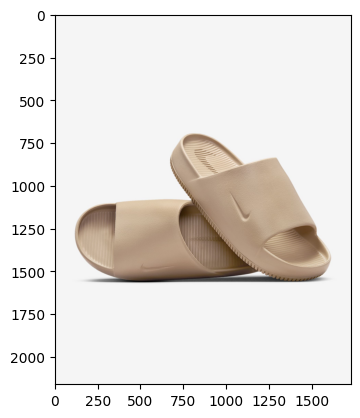

In [166]:


plt.imshow(image)
plt.show()

In [179]:
message = HumanMessage(
    content=[
        {
            "type": "text",
            "text": image_caption,
        }
    ]
)

In [184]:
result = full_chain.invoke([message])

In [185]:
display(Markdown(result))

You can find grey and white Nike sneakers at various retail stores and online marketplaces. Some popular options include:

* Nike Official Website (online)
* Nike Retail Stores (located in major cities worldwide)
* Foot Locker (located in malls and shopping districts)
* Finish Line (located in malls and online)
* Sports Authority (located in some areas, but mostly online)

You can also check with local shoe stores in your area for availability.